In [14]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from pandas_ta.volatility import kc 

df = pd.read_csv("../data/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[0:5000]
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')

df['ema25'] = df['Close'].ewm(span=25, adjust=False).mean()
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=30).mean()

df.reset_index(drop=True, inplace=True)
df=df[df.High!=df.Low]

# Bolinger Bands
df.ta.bbands(append=True, length=20, std=2)

# Initialize Keltner Channel Indictor
kc=kc(high=df['High'], low=df['Low'], close=df["Close"], window=20)

#Bolinger Band Upper - Keltner Channel Upper
df['bbu_minus_kcu'] = df['BBU_20_2.0'] - kc['KCUe_20_2']

pd.options.mode.copy_on_write = True

In [15]:
import enum
class EMA25(enum.Enum):
    PRICE_ACCION_NEUTRAL = 0
    PRICE_ACCION_UNDER = 1
    PRICE_ACCION_OVER = 2
    
class TREND(enum.Enum):
    NEUTRAL = 0
    UP = 1
    DOWN = 2

In [34]:
def detectDailyTrendLongTerm():

    import pandas as pd
    import pandas_ta as ta
    from scipy.signal import savgol_filter
    from scipy.signal import find_peaks

    df = pd.read_csv("../data/MSFT.USUSD_Candlestick_1_D_ASK_05.10.2022-05.10.2024.csv")
    df2=df[-300:]
    df2=df2[df2['Volume']!=0]
    
    ## Take the rolling atr so the yaxis doesn't shake too much 
    df2["atr"] = ta.atr(high=df2.High, low=df2.Low, close=df2.Close)
    df2["atr"] = df2.atr.rolling(window=30).mean()
    
    df2.reset_index(drop=True, inplace=True)

    df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)
    
    atr = df2.atr.iloc[-1] # all the first atrs are NaN
    peaks_idx, _ = find_peaks(df2.close_smooth, distance = 15, width = 3, prominence=atr)
    troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 15,width = 3, prominence=atr)

    '''
    Check if we are on a up trend
    '''
    up_run_length = 0
    up_run = True
    while up_run:
        if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
            break
            
        if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
           df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
            up_run_length += 1
        else:
            up_run = False    
          
    '''
    Check if we are on a down trend
    '''
    down_run_length = 0
    down_run = True
    while down_run:
        if 2 + down_run_length > len(peaks_idx) or 2 + down_run_length > len(troughs_idx):
            break
        
        if df2.close_smooth.iloc[peaks_idx[-1 - down_run_length]] < df2.close_smooth.iloc[peaks_idx[-2 - down_run_length]] and \
           df2.close_smooth.iloc[troughs_idx[-1 - down_run_length]] < df2.close_smooth.iloc[troughs_idx[-2 - down_run_length]]:
            down_run_length += 1
        else:
            down_run = False 
    
    if up_run_length > 0:
        return TREND['UP'].value
    elif down_run_length > 0:
        return TREND['DOWN'].value
    else:
        return TREND['NEUTRAL'].value

In [35]:
def detectDailyTrendShortTerm():

    import pandas as pd
    import pandas_ta as ta
    from scipy.signal import savgol_filter
    from scipy.signal import find_peaks

    df = pd.read_csv("../data/MSFT.USUSD_Candlestick_1_D_ASK_05.10.2022-05.10.2024.csv")
    df2=df[-200:]
    df2=df2[df2['Volume']!=0]
    
    ## Take the rolling atr so the yaxis doesn't shake too much 
    df2["atr"] = ta.atr(high=df2.High, low=df2.Low, close=df2.Close)
    df2["atr"] = df2.atr.rolling(window=20).mean()
    
    df2.reset_index(drop=True, inplace=True)

    df2["close_smooth"] = savgol_filter(df2.Close, 8, 5)
    
    atr = df2.atr.iloc[-1] # all the first atrs are NaN
    peaks_idx, _ = find_peaks(df2.close_smooth, distance = 5, width = 3, prominence=atr)
    troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 5,width = 3, prominence=atr)

    '''
    Check if we are on a up trend
    '''
    up_run_length = 0
    up_run = True
    while up_run:
        if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
            break
            
        if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
           df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
            up_run_length += 1
        else:
            up_run = False    
          
    '''
    Check if we are on a down trend
    '''
    down_run_length = 0
    down_run = True
    while down_run:
        if 2 + down_run_length > len(peaks_idx) or 2 + down_run_length > len(troughs_idx):
            break
        
        if df2.close_smooth.iloc[peaks_idx[-1 - down_run_length]] < df2.close_smooth.iloc[peaks_idx[-2 - down_run_length]] and \
           df2.close_smooth.iloc[troughs_idx[-1 - down_run_length]] < df2.close_smooth.iloc[troughs_idx[-2 - down_run_length]]:
            down_run_length += 1
        else:
            down_run = False 
    
    if up_run_length > 0:
        return TREND['UP'].value
    elif down_run_length > 0:
        return TREND['DOWN'].value
    else:
        return TREND['NEUTRAL'].value

In [36]:
def detectSqueeze(candle):

    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 
    isSqueeze = EMA25['PRICE_ACCION_NEUTRAL'].value
    
    if (df.iloc[candle]).bbu_minus_kcu<=0:
        if close<ema25:
            isSqueeze = EMA25['PRICE_ACCION_UNDER'].value
        else:
            isSqueeze = EMA25['PRICE_ACCION_OVER'].value
            
    return isSqueeze  

def detectSqueezeCloseToEMA(candle):

    isSqueeze = EMA25['PRICE_ACCION_NEUTRAL'].value
    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 
    high = (df.iloc[candle]).High
    low = (df.iloc[candle]).Low
    squeeze = (df.iloc[candle])['squeeze']
    zoneWidth = .30
    
    if squeeze==1:
        
        if (abs(low-ema25) <= zoneWidth):
            isSqueeze = EMA25['PRICE_ACCION_OVER'].value

        if (abs(high-ema25) <= zoneWidth):
            isSqueeze = EMA25['PRICE_ACCION_UNDER'].value
            
    return isSqueeze

def detectPosibleBreak(candle):

    window = 3
    posibleBreak = EMA25['PRICE_ACCION_NEUTRAL'].value
    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 
    squeezeCloseToEma = (df.iloc[candle]).squeezeCloseToEma 

    if (candle <= (window)) or (candle+window+1 >= len(df)):
        return posibleBreak
    
    localdf = df.iloc[candle-window:candle]

    val = localdf[localdf['squeezeCloseToEma'] == EMA25['PRICE_ACCION_UNDER'].value]
    
    lastTreeUnder = localdf[localdf['squeezeCloseToEma'] == EMA25['PRICE_ACCION_UNDER'].value].tail(3).values
    lastTreeOver = localdf[localdf['squeezeCloseToEma'] == EMA25['PRICE_ACCION_OVER'].value].tail(3).values

    if len(lastTreeUnder) == window and close<ema25 and squeezeCloseToEma:
        posibleBreak = EMA25['PRICE_ACCION_UNDER'].value
    elif len(lastTreeOver) == window and close>ema25 and squeezeCloseToEma:
        posibleBreak = EMA25['PRICE_ACCION_OVER'].value
    else:
        posibleBreak = EMA25['PRICE_ACCION_NEUTRAL'].value
            
    return posibleBreak

df['trendDaylyShortTerm'] = detectDailyTrendShortTerm()
df['trendDaylyLongTerm'] = detectDailyTrendLongTerm()
df['squeeze'] = df.apply(lambda row: detectSqueeze(row.name), axis=1)
df['squeezeCloseToEma'] = df.apply(lambda row: detectSqueezeCloseToEMA(row.name), axis=1)
df['posibleBreak'] = df.apply(lambda row: detectPosibleBreak(row.name), axis=1)

#df.to_csv('squezze.csv', index=False)

In [31]:
def posibleBreakArea(x):
    extraSpace = 1
    if (x['posibleBreak']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['posibleBreak']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace    
    else:
        return np.nan
        
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeeze']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeeze']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan

df['squezzeArea'] = df.apply(lambda row: squezzeArea(row), axis=1)
df['squeezeCloseToEmaArea'] = df.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
df['posibleBreakArea'] = df.apply(lambda row: posibleBreakArea(row), axis=1)

#df.to_csv('squezze.csv', index=False)

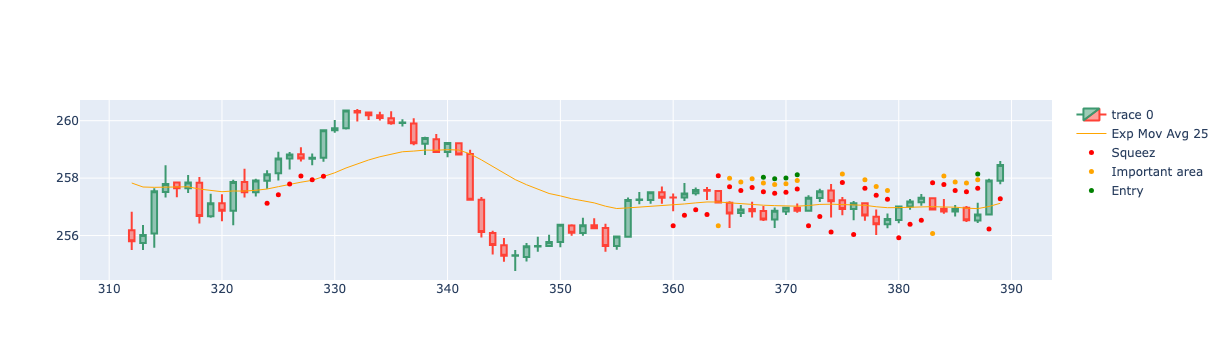

In [37]:
import plotly.io as pio
import plotly.graph_objects as go  

'''
0:78      *
78:156    ?
156:234   ?
234:312   x
312:390   *
390:468   x
468:546   *
546:624   *
624:702   * 
702:780   *
780:858   *
858:936   x
936:1014  x
1014:1092 x
1092:1170 *
1170:1248 ?
1248:1326 x
1326:1404 *
1404:1482 x
1482:1560 *
1560:1638 x
1638:1716 ?
1716:1794 x
1794:1872 *
1872:1950 *
1950:2028 x
2028:2106 *
2106:2184 x
2184:2262 x
2262:2340 ?
2340:2418 *
2418:2496 *
2496:2574 x
2574:2652 x
2652:2730 x
2730:2808 *
'''
dfpl = df[312:390]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl.index,
            open=dfpl['Open'],
            high=dfpl['High'],
            low=dfpl['Low'],
            close=dfpl['Close']),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema25'],
            line=dict(color='orange', width=1), 
            name="Exp Mov Avg 25")
    ]
)

fig.add_scatter(x=dfpl.index, y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl.index, y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl.index, y=dfpl['posibleBreakArea'], mode="markers", marker=dict(size=5, color="green"), name="Entry")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()